In [91]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats as sps
from scipy import stats, optimize
from scipy.special import digamma, polygamma
from matplotlib.patches import Patch
import single_sample_transcript_outlier_analysis as ss

Identify expression outliers for each sample
-

In [ ]:
# transcript to gene metadata
meta = pd.read_csv("applied_depletion_gregor_n100/gencode.v49.metadata.HGNC", sep="\t", header=None)
meta.columns = ["Transcript", "Gene name", "HGNC"]
meta['Transcript stable ID'] = meta['Transcript'].str.split('.').str[0]
meta.set_index('Transcript stable ID', inplace=True)
meta = meta[~meta.index.duplicated(keep='first')]
meta = meta['Gene name'].copy()
meta

Transcript stable ID
ENST00000511072       PRDM16
ENST00000607632       PRDM16
ENST00000378391       PRDM16
ENST00000514189       PRDM16
ENST00000270722       PRDM16
                     ...    
ENST00000710671      CCDC120
ENST00000710672      CCDC120
ENST00000400754        MAFIP
ENST00000611446    RNA5-8SN5
ENST00000616292    RNA5-8SN4
Name: Gene name, Length: 412781, dtype: object

In [84]:
#break isoforms counts into 2 groups for control and depleted
data = pd.read_csv("applied_depletion_gregor_n100/rsem/isoforms_TPM.tsv", sep="\t")

data_wm = data.loc[:, data.columns.str.contains('-WM') | data.columns.str.contains('transcript_id')].copy()
data_wm = data_wm.fillna(0)

data_d = data.loc[:, data.columns.str.contains('-D') | data.columns.str.contains('transcript_id')].copy()
data_d = data_d.fillna(0)

In [ ]:
samples_candidate_genes = ['1-1', '1-2', '1-3', '1-4', '1-5', '1-6', '1-7', '1-8',
                           '2-1', '2-2', '2-3', '2-4', '2-5', '2-6', '2-7', '2-8',
                           '3-1', '3-2', '3-3', '3-4', '3-5', '3-6', '3-7', '3-8',
                           '4-1', '4-2', '4-3', '4-4', '4-5', '4-6', '4-7', '4-8',
                           '5-1', '5-2', '5-3', '5-4', '5-5', '5-6', '5-7', '5-8',
                           '6-1', '6-2', '6-3', '6-4', '6-5', '6-6', '6-7', '6-8',
                           '7-1', '7-2', '7-3', '7-4', '7-5', '7-6', '7-7', '7-8',
                           '8-1', '8-2', '8-3', '8-4', '8-5', '8-6', '8-7', '8-8',
                           '9-1', '9-2', '9-3', '9-4', '9-5', '9-6', '9-7', '9-8',
                           '10-1', '10-2', '10-3', '10-4', '10-5', '10-6', '10-7', '10-8',
                           '11-1', '11-2', '11-3', '11-4', '11-5', '11-6', '11-7', '11-8',
                           '12-1', '12-2', '12-3', '12-4', '12-5', '12-6', '12-7', '12-8']
tpm_cutoff = 0.1
min_prop = 0.05

frames = []

for sample in samples_candidate_genes:
    print(f"Processing sample: {sample}")

    control_sample = f"{sample}-WM"
    depleted_sample = f"{sample}-D"

    # Control
    results_wm = ss.eb_robust_outliers_for_sample(
        data=data_wm,
        sample_col=control_sample,
        id_col="transcript_id",
        tpm_cutoff=tpm_cutoff,
        min_prop=min_prop,
        target_tpm_keep=0.1,
        pseudo=1.0,
        robust_z_thresh=4.0,
        pct_hi_thresh=0.99,
        pct_lo_thresh=0.01,
        q_thresh=0.05,
        min_abs_diff_log2=1.0,
    )
    sig_wm = results_wm.query("final_any_flag").copy()
    sig_wm["condition"] = "Control"
    sig_wm["sample_base"] = sample

    # Depleted
    results_d = ss.eb_robust_outliers_for_sample(
        data=data_d,
        sample_col=depleted_sample,
        id_col="transcript_id",
        tpm_cutoff=tpm_cutoff,
        min_prop=min_prop,
        target_tpm_keep=0.1,
        pseudo=1.0,
        robust_z_thresh=4.0,
        pct_hi_thresh=0.99,
        pct_lo_thresh=0.01,
        q_thresh=0.05,
        min_abs_diff_log2=1.0,
    )
    sig_d = results_d.query("final_any_flag").copy()
    sig_d["condition"] = "Depleted"
    sig_d["sample_base"] = sample

    frames.extend([sig_wm, sig_d])

combined = pd.concat(frames, ignore_index=True)

Processing sample: 1-1
Keeping 152575 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Keeping 162235 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Processing sample: 1-2
Keeping 151771 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Keeping 161658 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Processing sample: 1-3
Keeping 152163 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Keeping 161636 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Processing sample: 1-4
Keeping 151478 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Keeping 161613 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Processing sample: 1-5
Keeping 151931 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Keeping 161927 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Processing sample: 1-6
Keeping 152132 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at

In [86]:
#identify the spliceopathy samples
samples = ['3-2', '5-4', '5-7']
combined['sample'] = combined['sample_base']
combined['splice'] = combined['sample'].apply(lambda x: 'Spliceopathy' if x in samples else 'Other')
combined['condition'] = combined['condition'].replace({'Control': 'Standard'})

#save outlier information
combined.to_csv("applied_depletion_gregor_n100/rsem/expression_outliers.csv", index=False)
combined

,transcript_id,sample,TPM_sample,mean_TPM_others,median_TPM_others,log2TPM_sample,mean_log2TPM_others,median_log2TPM_others,diff_log2_mean,diff_log2_median,...,direction,robust_high_flag,robust_low_flag,eb_flag,final_high_flag,final_low_flag,final_any_flag,condition,sample_base,splice
0,ENST00000540548.1,1-1,11.03,0.000000,0.00,3.588565,0.000000,0.000000,3.588565,3.588565,...,higher_in_sample,True,False,True,True,False,True,Standard,1-1,Other
1,ENST00000676400.1,1-1,4.40,0.000000,0.00,2.432959,0.000000,0.000000,2.432959,2.432959,...,higher_in_sample,True,False,True,True,False,True,Standard,1-1,Other
2,ENST00000481033.1,1-1,3.93,0.000000,0.00,2.301588,0.000000,0.000000,2.301588,2.301588,...,higher_in_sample,True,False,True,True,False,True,Standard,1-1,Other
3,ENST00000752418.1,1-1,2.41,0.000000,0.00,1.769772,0.000000,0.000000,1.769772,1.769772,...,higher_in_sample,True,False,True,True,False,True,Standard,1-1,Other
4,ENST00000738168.1,1-1,1.39,0.000000,0.00,1.257011,0.000000,0.000000,1.257011,1.257011,...,higher_in_sample,True,False,True,True,False,True,Standard,1-1,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57189,ENST00000341464.9,12-8,2.04,0.529895,0.46,1.604071,0.581877,0.545968,1.022194,1.058103,...,higher_in_sample,True,False,True,True,False,True,Depleted,12-8,Other
57190,ENST00000686524.3,12-8,3.17,0.556211,0.48,2.060047,0.569194,0.565597,1.490853,1.494450,...,higher_in_sample,True,False,True,True,False,True,Depleted,12-8,Other
57191,ENST00000368107.2,12-8,0.00,1.530000,1.38,0.000000,1.289033,1.250962,-1.289033,-1.250962,...,lower_in_sample,False,True,True,False,True,True,Depleted,12-8,Other
57192,ENST00000430789.1,12-8,2.05,0.208421,0.00,1.608809,0.196048,0.000000,1.412761,1.608809,...,higher_in_sample,True,False,True,True,False,True,Depleted,12-8,Other


In [87]:
palette_raw = {
    "Standard": "lightgrey",
    "Depleted": "#4F5D2F",
    "Combined": "#A6C48A",
}
cond_to_color = {
    "Standard": palette_raw["Standard"],
    "Depleted": palette_raw["Depleted"],
    "Combined": palette_raw["Combined"],
}

def compute_outlier_counts_by_splice(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build tidy counts for per-sample outliers with y-axis='splice' and hue='condition':
      - Counts for Control/Depleted = number of rows per (sample, splice, condition)
      - Combined = unique transcript_id across Control+Depleted per (sample, splice)
    Only observed (sample, splice) pairs appear; no zero-filled rows for missing combos.
    Condition labels are normalized so 'Standard' -> 'Control', etc.
    """
    req = {"transcript_id", "sample", "condition", "splice"}
    missing = req - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df.copy()
    df["condition_label"] = df['condition']

    # Keep only the two base conditions for counts
    base_mask = df["condition_label"].isin(["Standard", "Depleted"])
    df_base = df.loc[base_mask].copy()

    # Counts (observed combos only)
    by_ssc = (
        df_base.groupby(["sample", "splice", "condition_label"], dropna=False)
        .size().rename("count").reset_index()
    )

    # Combined = union across Control/Depleted per (sample, splice)
    combined_counts = (
        df_base.groupby(["sample", "splice"])["transcript_id"]
        .nunique()
        .rename("count").reset_index()
        .assign(condition_label="Combined")
    )

    tidy = pd.concat([by_ssc, combined_counts], ignore_index=True)

    # Order and filter strictly to our three labels
    order = ["Standard", "Depleted", "Combined"]
    tidy = tidy[tidy["condition_label"].isin(order)].copy()
    tidy["condition_label"] = pd.Categorical(tidy["condition_label"], categories=order, ordered=True)

    return tidy.sort_values(["splice", "condition_label", "sample"]).reset_index(drop=True)

305.0
629.0
95.0
274.0


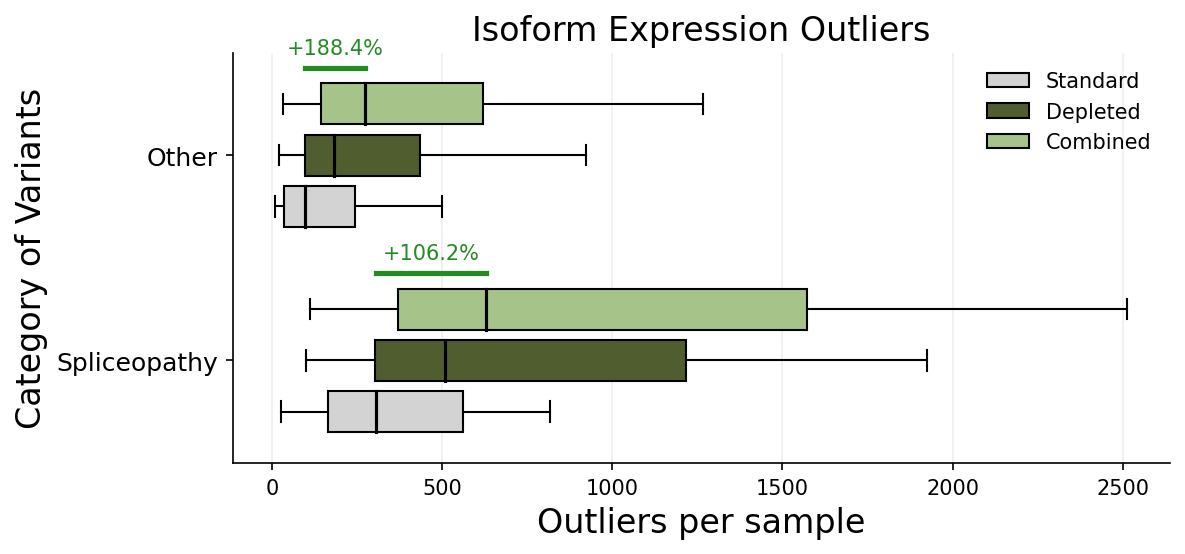

In [88]:
tidy_counts = compute_outlier_counts_by_splice(combined)
order_cond = ["Standard", "Depleted", "Combined"]
splice_levels = list(tidy_counts["splice"].dropna().unique())
splice_levels = splice_levels[::-1]

# Collect values per splice & condition (only if present)
data_map = {sp: {c: [] for c in order_cond} for sp in splice_levels}
for sp in splice_levels:
    for c in order_cond:
        vals = tidy_counts.loc[
            (tidy_counts["splice"] == sp) & (tidy_counts["condition_label"] == c),
            "count"
        ].to_numpy()
        if vals.size > 0:
            data_map[sp][c] = vals

fig_height = max(2.5, 0.8 * len(splice_levels) + 2.2)
fig, ax = plt.subplots(figsize=(8, fig_height), dpi=150)

gap = 2
offsets = [-0.5, 0, 0.5]
y_centers = np.arange(len(splice_levels)) * gap

for i, sp in enumerate(splice_levels):
    for j, c in enumerate(order_cond):
        vals = data_map[sp][c]
        if len(vals) == 0:
            continue
        y_pos = y_centers[i] + offsets[j]
        bp = ax.boxplot(
            vals,
            vert=False,
            positions=[y_pos],
            widths=0.4,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(linewidth=1.5),
            boxprops=dict(linewidth=1.0),
            whiskerprops=dict(linewidth=1.0),
            capprops=dict(linewidth=1.0),
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(cond_to_color[c])
            patch.set_edgecolor("black")
        for median in bp["medians"]:
            median.set_color("black")

ax.set_xlabel("Outliers per sample", fontsize=16)
ax.set_yticks(y_centers)
ax.set_yticklabels(splice_levels, fontsize=12)
ax.set_ylabel("Category of Variants", fontsize=16)
ax.set_title("Isoform Expression Outliers", fontsize=16)
ax.grid(axis="x", alpha=0.2)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

legend_handles = [
    Patch(facecolor=cond_to_color["Standard"], edgecolor="black", label="Standard"),
    Patch(facecolor=cond_to_color["Depleted"], edgecolor="black", label="Depleted"),
    Patch(facecolor=cond_to_color["Combined"], edgecolor="black", label="Combined"),
]
ax.legend(handles=legend_handles, frameon=False, loc="upper right")

for i, sp in enumerate(splice_levels):
    vals_std = data_map[sp]["Standard"]
    vals_comb = data_map[sp]["Combined"]
    if len(vals_std) == 0 or len(vals_comb) == 0:
        continue

    # Compute medians
    med_std = np.median(vals_std)
    print(med_std)
    med_comb = np.median(vals_comb)
    print(med_comb)

    # prcent increase from standard to combined
    if med_std != 0:
        pct_gain = ((med_comb - med_std) / med_std) * 100.0
    else:
        pct_gain = np.nan

    # Position of the green line (slightly above the combined box)
    y_line = y_centers[i] + 0.5 + 0.35  

    # Draw line from median(Standard) → median(Combined)
    ax.plot(
        [med_std, med_comb],
        [y_line, y_line],
        color="forestgreen",
        linewidth=2.5,
    )

    # Add percent gain text above the line
    ax.text(
        (med_std + med_comb) / 2,
        y_line + 0.1,  
        f"+{pct_gain:.1f}%",
        color="forestgreen",
        fontsize=10,
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.savefig("applied_depletion_gregor_n100/paper_figures/isoform_expression_outliers.png", dpi=300)
plt.show()

In [89]:
tidy_counts.groupby(['condition_label', 'splice'])['count'].median()

/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_58613/2973178639.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tidy_counts.groupby(['condition_label', 'splice'])['count'].median()


condition_label  splice      
Standard         Other            95.0
                 Spliceopathy    305.0
Depleted         Other           181.0
                 Spliceopathy    507.0
Combined         Other           274.0
                 Spliceopathy    629.0
Name: count, dtype: float64

In [90]:
tidy_counts.groupby(['condition_label'])['count'].median()

/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_58613/2766695933.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tidy_counts.groupby(['condition_label'])['count'].median()


condition_label
Standard     96.5
Depleted    184.5
Combined    275.0
Name: count, dtype: float64

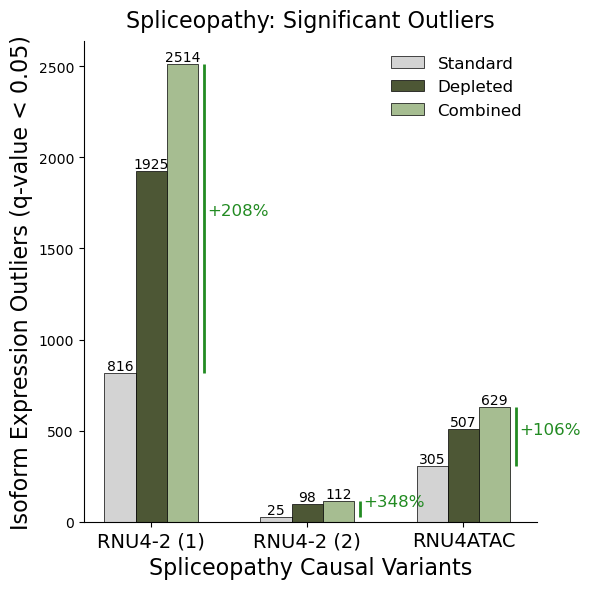

In [21]:
# --- Prepare data as before ---
splice = combined[combined['splice'] == 'Spliceopathy'].copy()
sample_rename = {'3-2': 'RNU4ATAC', '5-4': 'RNU4-2 (1)', '5-7': 'RNU4-2 (2)'}
splice['sample'] = splice['sample'].replace(sample_rename)

# Counts per sample per condition
counts_std_dep = splice.groupby(['sample', 'condition'])['transcript_id'].nunique().reset_index()
counts_std_dep.rename(columns={'transcript_id': 'count'}, inplace=True)

# Combined = unique transcripts across both Standard + Depleted
combined_counts = (
    splice.groupby('sample')['transcript_id']
    .nunique()
    .reset_index()
    .assign(condition='Combined')
    .rename(columns={'transcript_id': 'count'})
)

total_counts = pd.concat([counts_std_dep, combined_counts], ignore_index=True)

# Order conditions
condition_order = ['Standard', 'Depleted', 'Combined']
total_counts['condition'] = pd.Categorical(total_counts['condition'], categories=condition_order, ordered=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 6))
sns.barplot(
    data=total_counts,
    x='sample',
    y='count',
    hue='condition',
    palette=['lightgrey', '#4F5D2F', '#A6C48A'],
    edgecolor='black',
    linewidth=0.5,
    width=0.6,
    ax=ax
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

# Identify bar containers by hue order (must match your palette / condition_order)
condition_order = ['Standard', 'Depleted', 'Combined']
containers = ax.containers  # list[BarContainer], one per hue in order

# Map hue -> container index
hue_to_idx = {h: i for i, h in enumerate(condition_order)}

# Short-cuts to the two we need
std_idx = hue_to_idx['Standard']
comb_idx = hue_to_idx['Combined']

# Safety: ensure we have both containers
if std_idx < len(containers) and comb_idx < len(containers):
    std_bars  = containers[std_idx]
    comb_bars = containers[comb_idx]

    # Iterate over samples (bars align by index across containers)
    for k, comb_bar in enumerate(comb_bars):
        # Combined bar geometry
        x_comb_left  = comb_bar.get_x()
        w_comb       = comb_bar.get_width()
        x_comb_right = x_comb_left + w_comb
        h_comb       = comb_bar.get_height()

        # Matching Standard bar
        if k >= len(std_bars):
            continue
        h_std = std_bars[k].get_height()

        # If either bar missing, skip
        if h_std is None or h_comb is None:
            continue

        # Percent gain relative to Standard
        pct_gain = ((h_comb - h_std) / h_std * 100.0) if h_std != 0 else np.nan

        # Vertical line just to the RIGHT of the combined bar
        x_line = x_comb_right + (0.20 * w_comb)  # nudge right ~6% of a bar width
        y0, y1 = sorted([h_std, h_comb])

        ax.vlines(x_line, y0, y1, colors='forestgreen', linewidth=2)

        # Percent label to the right of the line, slightly above the higher value
        label = f"{pct_gain:+.0f}%" if np.isfinite(pct_gain) else "NA"
        ax.text(
            x_line + 0.08 * w_comb,   # further right
            (y0 + y1) / 2,             # make it in the middle of the line
            label,
            color='forestgreen',
            fontsize=12,
            va='bottom',
            ha='left'
        )

# Style
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xticks(ax.get_xticks(), labels=ax.get_xticklabels(), fontsize=14)
plt.xlabel("Spliceopathy Causal Variants", fontsize=16)
plt.ylabel("Isoform Expression Outliers (q-value < 0.05)", fontsize=16)
plt.title("Spliceopathy: Significant Outliers", fontsize=16, pad=10)
plt.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.savefig("applied_depletion_gregor_n100/paper_figures/isoform_expression_outliers_spliceopathy_barplot.png", dpi=300)
plt.show()

In [22]:
splice

,transcript_id,sample,TPM_sample,mean_TPM_others,median_TPM_others,log2TPM_sample,mean_log2TPM_others,median_log2TPM_others,diff_log2_mean,diff_log2_median,...,direction,robust_high_flag,robust_low_flag,eb_flag,final_high_flag,final_low_flag,final_any_flag,condition,sample_base,splice
20742,ENST00000583339.3,RNU4ATAC,4.13,0.000000,0.00,2.358959,0.000000,0.000000,2.358959,2.358959,...,higher_in_sample,True,False,True,True,False,True,Standard,3-2,Spliceopathy
20743,ENST00000723795.1,RNU4ATAC,2.11,0.000000,0.00,1.636915,0.000000,0.000000,1.636915,1.636915,...,higher_in_sample,True,False,True,True,False,True,Standard,3-2,Spliceopathy
20744,ENST00000723701.1,RNU4ATAC,2.04,0.000000,0.00,1.604071,0.000000,0.000000,1.604071,1.604071,...,higher_in_sample,True,False,True,True,False,True,Standard,3-2,Spliceopathy
20745,ENST00000625124.1,RNU4ATAC,1.75,0.000000,0.00,1.459432,0.000000,0.000000,1.459432,1.459432,...,higher_in_sample,True,False,True,True,False,True,Standard,3-2,Spliceopathy
20746,ENST00000512192.1,RNU4ATAC,1.43,0.000000,0.00,1.280956,0.000000,0.000000,1.280956,1.280956,...,higher_in_sample,True,False,True,True,False,True,Standard,3-2,Spliceopathy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33184,ENST00000538162.3,RNU4-2 (2),1.42,0.158421,0.00,1.275007,0.181194,0.000000,1.093813,1.275007,...,higher_in_sample,True,False,True,True,False,True,Depleted,5-7,Spliceopathy
33185,ENST00000701199.1,RNU4-2 (2),2.23,0.233053,0.08,1.691534,0.239988,0.111031,1.451546,1.580503,...,higher_in_sample,True,False,True,True,False,True,Depleted,5-7,Spliceopathy
33186,ENST00000648457.2,RNU4-2 (2),1.02,0.102632,0.00,1.014355,0.119644,0.000000,0.894711,1.014355,...,higher_in_sample,True,False,True,True,False,True,Depleted,5-7,Spliceopathy
33187,ENST00000704269.1,RNU4-2 (2),1.33,0.106842,0.00,1.220330,0.108701,0.000000,1.111629,1.220330,...,higher_in_sample,True,False,True,True,False,True,Depleted,5-7,Spliceopathy


In [ ]:
#generate unique outliers --> Genes for depletion for ENRICHR GSEA testing
import os
outdir = "applied_depletion_gregor_n100/paper_figures"
os.makedirs(outdir, exist_ok=True)

# Strip version numbers from meta index for matching
meta.index = meta.index.to_series().str.replace(r"\.\d+$", "", regex=True)

for sample in splice["sample"].unique():
    # Isoforms only found in Depleted
    depleted_ids = splice.loc[
        (splice["sample"] == sample) & (splice["condition"] == "Depleted"),
        "transcript_id"
    ].unique()
    control_ids = splice.loc[
        (splice["sample"] == sample) & (splice["condition"] == "Standard"),
        "transcript_id"
    ].unique()

    unique_depleted = set(depleted_ids) - set(control_ids)
    print(f"Sample: {sample}, Unique Depleted Isoforms: {len(unique_depleted)}")

    # Remove version numbers to match meta index
    unique_depleted_nover = [tid.split(".")[0] for tid in unique_depleted]

    # Lookup gene names directly in the Series
    gene_names = meta.reindex(unique_depleted_nover).dropna().unique()
    print(f"Sample: {sample}, Unique Depleted Genes: {len(gene_names)}")

    # Write to file
    outfile = os.path.join(outdir, f"{sample}_unique_depleted_isoforms.txt")
    with open(outfile, "w") as f:
        for gene in sorted(gene_names):
            f.write(f"{gene}\n")

Sample: RNU4ATAC, Unique Depleted Isoforms: 324
Sample: RNU4ATAC, Unique Depleted Genes: 206
Sample: RNU4-2 (1), Unique Depleted Isoforms: 1698
Sample: RNU4-2 (1), Unique Depleted Genes: 1230
Sample: RNU4-2 (2), Unique Depleted Isoforms: 87
Sample: RNU4-2 (2), Unique Depleted Genes: 67


GSEA plotting
-

In [ ]:
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
def plot_enrichment_lollipop(df: pd.DataFrame, 
                             top_n=10, 
                             title="Top Enriched Terms",
                             save=False,
                             savefile="GREGOR_GUIDE/figures/enrichment_lollipop.png"):
    """
    Lollipop chart for enrichment results with:
      - X: Combined Score
      - Y: Term
      - Dot size: Overlap Count
      - Dot color: -log10(P-value) (darker green = more significant)
      - Right-side: colorbar (-log10(P-value)) + bubble size legend
    """

    # --- Check columns ---
    required_cols = ["Term", "Overlap", "P-value", "Adjusted P-value", "Combined Score"]
    if not all(c in df.columns for c in required_cols):
        raise ValueError(f"DataFrame must contain columns: {required_cols}")

    # Work on a copy
    df = df.copy()

    # Parse "157/796" -> 157
    df["Overlap Count"] = df["Overlap"].astype(str).str.split("/").str[0].astype(int)

    # Compute -log10(P-value) for color mapping
    # Protect against p=0
    df["-log10 P"] = -np.log10(df["P-value"].clip(lower=1e-300))

    # Select top terms by highest Combined Score
    top_df = df.nlargest(top_n, "Combined Score").iloc[::-1]  # reverse for top-down plotting

    # --- Colormap setup ---
    # darkest green = highest -log10(P)
    cmap = mpl.cm.Greens
    vmin, vmax = top_df["-log10 P"].min(), top_df["-log10 P"].max()
    if vmin == vmax:
        vmax = vmin + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # --- Plot setup ---
    fig, ax = plt.subplots(figsize=(3.8, 0.3 * top_n + 0.6), dpi=150)
    y_positions = np.arange(len(top_df))

    # Lollipop stems
    ax.hlines(
        y=y_positions,
        xmin=0,
        xmax=top_df["Combined Score"],
        color="lightgray",
        lw=2,
        zorder=1
    )

    # Size scaling
    def size_scale(n_genes):
        return np.sqrt(n_genes) * 20

    # Scatter points
    sc = ax.scatter(
        top_df["Combined Score"],
        y_positions,
        s=size_scale(top_df["Overlap Count"]),
        c=top_df["-log10 P"],
        cmap=cmap,
        norm=norm,
        edgecolor="black",
        linewidth=0.5,
        zorder=3
    )

    # --- Axes formatting ---
    ax.set_yticks(y_positions)
    ax.set_yticklabels(top_df["Term"], fontsize=11)
    ax.set_xlabel("Combined Score", fontsize=13)
    ax.set_ylabel("")
    ax.set_title(title, fontsize=15, pad=15)

    # Add vertical padding so top/bottom circles do not get cut off
    ax.set_ylim(-0.75, len(top_df) - 0.25)

    # Give a bit of right margin for colorbar + size legend
    plt.subplots_adjust(right=0.78)

    # --- Right-side colorbar (-log10(P-value)) ---
    cax = inset_axes(
        ax,
        width="3%",
        height="55%",
        loc="center left",
        bbox_to_anchor=(1.1, 0.12, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cax)
    cbar.set_label("-log10(P-value)", fontsize=9, rotation=270, labelpad=14)
    cbar.ax.tick_params(labelsize=9)

    # --- Bubble size legend ---
    sax = inset_axes(
        ax,
        width="16%",
        height="28%",
        loc="lower left",
        bbox_to_anchor=(1.01, -0.3, 1, 1.8),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    sax.set_xlim(0, 1)
    sax.set_ylim(0, 1)
    sax.axis("off")

    bubble_vals = [50, 25, 5]
    ys = [0.7, 0.45, 0.2]
    x_bub = 0.35
    x_txt = 0.68

    for y, v in zip(ys, bubble_vals):
        sax.scatter(
            x_bub, y,
            s=size_scale(v),
            facecolor="lightgray",
            edgecolor="black",
            linewidth=0.5
        )
        sax.text(x_txt, y, f"{v}", va="center", ha="left", fontsize=9)

    sax.text(0.0, 0.95, "Overlap size", fontsize=10)

    # --- Styling ---
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    if save:
        plt.savefig(savefile, dpi=400, bbox_inches="tight")

    plt.show()

    return top_df

In [73]:
data = pd.read_csv('applied_depletion_gregor_n100/paper_figures/RNU4-2_Jensen_DISEASES_Curated_2025_table.txt', delimiter='\t')
data = data[data['Adjusted P-value'] < 0.05]
data = data.sort_values(by='Combined Score', ascending=False)
data.head(10)

,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
2,EPILEPSY,43/309,4.466690e-07,0.000049,0,0,2.520007,36.846149,PIGS;PIGT;PIGN;PIGQ;UBA5;PIGP;WDR4;PTPN23;CHD2...
0,CENTRAL NERVOUS SYSTEM DISEASE,96/874,1.922608e-08,0.000007,0,0,1.957754,34.783404,PIGS;NRP1;GSK3B;PIGT;PIGN;IFT172;PIGQ;PIGP;WDR...
1,BRAIN DISEASE,63/524,2.587935e-07,0.000046,0,0,2.144043,32.519198,PIGS;NRP1;PIGT;PIGN;IFT172;PIGQ;PIGP;WDR4;PTPN...
6,CONGENITAL NERVOUS SYSTEM ABNORMALITY,16/92,1.421057e-04,0.007268,0,0,3.241828,28.719157,POMT2;MACF1;ARFGEF2;PTCH1;POMT1;NEDD4L;MTHFR;D...
3,NERVOUS SYSTEM DISEASE,142/1540,5.419156e-07,0.000049,0,0,1.621818,23.399841,PANK4;NUP188;IFT172;CARF;GNAT2;NAGLU;TBC1D32;S...
7,NEURODEGENERATIVE DISEASE,48/463,2.808402e-04,0.012568,0,0,1.796098,14.687996,GSK3B;VCP;AP5Z1;UBA5;SPG7;PLA2G6;PLD3;SYNE1;DN...
4,DISEASE OF ANATOMICAL ENTITY,217/2727,2.542845e-05,0.001821,0,0,1.387705,14.681421,PANK4;MAPKBP1;SMARCAL1;IFT172;C4B;C4A;GNAT2;AK...
5,DISEASE,281/3737,9.157076e-05,0.005464,0,0,1.312064,12.200094,PANK4;MAPKBP1;SMARCAL1;PGAP2;IFT172;C4B;C4A;GN...
9,AUTOSOMAL RECESSIVE DISEASE,48/492,1.071839e-03,0.038372,0,0,1.676133,11.462034,POMT2;MAPKBP1;SMARCAL1;PGAP2;PIGO;TNFRSF13B;IF...
8,GENETIC DISEASE,132/1648,9.090951e-04,0.036162,0,0,1.368240,9.581866,PANK4;MAPKBP1;SMARCAL1;PGAP2;NUP188;IFT172;INP...


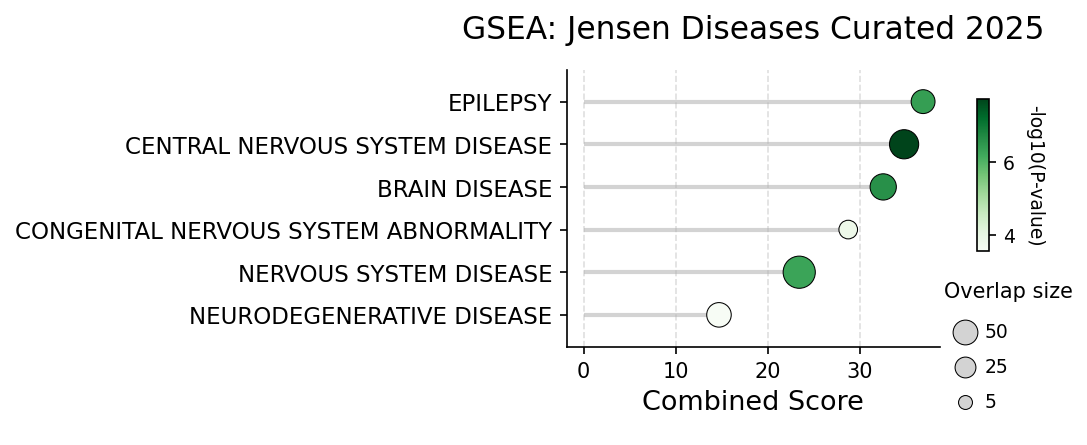

In [74]:
top_df = plot_enrichment_lollipop(data, top_n=6, title="GSEA: Jensen Diseases Curated 2025", save=True, 
                                 savefile="applied_depletion_gregor_n100/paper_figures/RNU4-2_Jensen_Diseases_curated_2025_enrichment_lollipop.png")